# 1. Data and Libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mglearn
from IPython import display
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, ward, average
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram


In [15]:
# loading the data from the CSV file

import pandas as pd

df_markets = pd.read_csv("../data/Polymarkets_Data_Cleaned.csv")

print(df_markets.shape)

(200000, 33)


In [16]:
# have a look at the data types and null values in the dataset

df_markets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 33 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    200000 non-null  int64  
 1   question              200000 non-null  object 
 2   startDateIso          193809 non-null  object 
 3   endDateIso            198219 non-null  object 
 4   volume                182492 non-null  float64
 5   liquidity             65287 non-null   float64
 6   outcomes              200000 non-null  object 
 7   outcomePrices         200000 non-null  object 
 8   competitive           65320 non-null   float64
 9   rewardsMinSize        200000 non-null  float64
 10  restricted            200000 non-null  int64  
 11  spread_poly           200000 non-null  float64
 12  bestBid               92730 non-null   float64
 13  bestAsk               199986 non-null  float64
 14  spread                92717 non-null   float64
 15  

**Selected clustering features:** `duration`, `rewardsMinSize`, `politics`, `sports`, `esports`, `crypto`, `finance`, `business`, `technology_ai`, `geopolitics`, `culture`, `science`, `number_of_categories`, `outcome_yes_no`, `outcome_up_down`, `outcome_over_under`, `outcome_other`

In [17]:
# Remove observations with missing duration
df_markets = df_markets.dropna(subset=["duration"]).reset_index(drop=True)

# Check the remaining number of observations
print(len(df_markets))

192466


In [20]:
numerical_features = [
    "duration",
    "rewardsMinSize",
    "number_of_categories"
]

dummy_features = [
    "politics",
    "sports",
    "esports",
    "crypto",
    "finance",
    "business",
    "technology_ai",
    "geopolitics",
    "culture",
    "science",
    "outcome_yes_no",
    "outcome_up_down",
    "outcome_over_under",
    "outcome_other"
]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_num = pd.DataFrame(
    scaler.fit_transform(df_markets[numerical_features]),
    columns=numerical_features,
    index=df_markets.index
)

In [22]:
X_dummy = df_markets[dummy_features]

In [23]:
X = pd.concat([X_num, X_dummy], axis=1)

# 2. k-means

## 2.1 Finding the

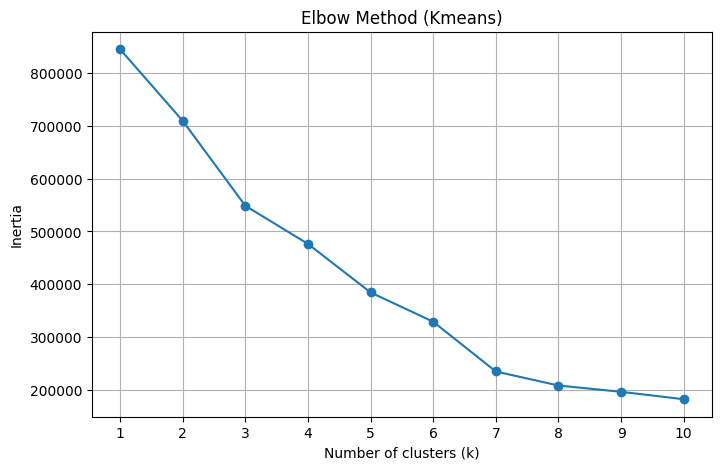

In [24]:
# Elbow Method
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method (Kmeans)")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

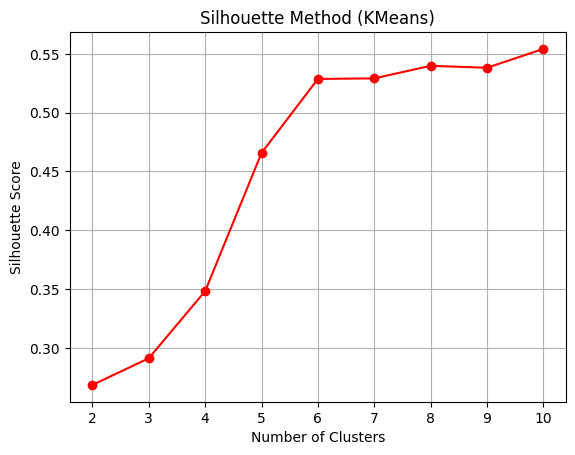

In [34]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

# Plot Silhouette Scores
plt.figure()
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method (KMeans)')
plt.grid(True)
plt.show()
plt.show()

The Elbow Method suggests potential solutions with **3, 5, and 7 clusters**, while the Silhouette Score indicates that **7 clusters** provide the highest clustering quality, followed by **5** and **3** clusters. Therefore, we consider all three solutions in the subsequent analysis and evaluate their usefulness based on predictive performance and interpretability.

## k = 3

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_markets["cluster_kmeans_3"] = kmeans.fit_predict(X)

print(df_markets["cluster_kmeans_3"].value_counts().sort_index())

cluster_kmeans_3
0    84239
1    96489
2    11738
Name: count, dtype: int64


In [53]:
df_markets.groupby("cluster_kmeans_3")[numerical_features + dummy_features].mean().round(2)

,duration,rewardsMinSize,number_of_categories,politics,sports,esports,crypto,finance,business,technology_ai,geopolitics,culture,science,outcome_yes_no,outcome_up_down,outcome_over_under,outcome_other
cluster_kmeans_3,,,,,,,,,,,,,,,,,
0,9.81,6.64,0.55,0.00,0.50,0.03,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.41,0.00,0.18,0.40
1,6.23,13.00,1.35,0.10,0.07,0.04,0.71,0.03,0.28,0.01,0.02,0.04,0.05,0.53,0.44,0.00,0.03
2,216.41,57.73,1.01,0.28,0.45,0.04,0.04,0.04,0.03,0.02,0.04,0.08,0.01,0.99,0.00,0.00,0.01


### Cluster interpretation

Based on the selected features, the K-Means algorithm identifies three distinct types of prediction markets:

- **Cluster 0 – Sports Markets:** Markets are primarily related to sports, have short durations, relatively low reward sizes, and include a variety of outcome types.

- **Cluster 1 – Crypto & Business Markets:** Markets are predominantly related to crypto and business, have short durations, moderate reward sizes, and consist mainly of *Yes/No* and *Up/Down* outcomes.

- **Cluster 2 – Long-Term High-Reward Markets:** Markets are characterized by long durations, high minimum rewards, and are almost exclusively *Yes/No* markets.

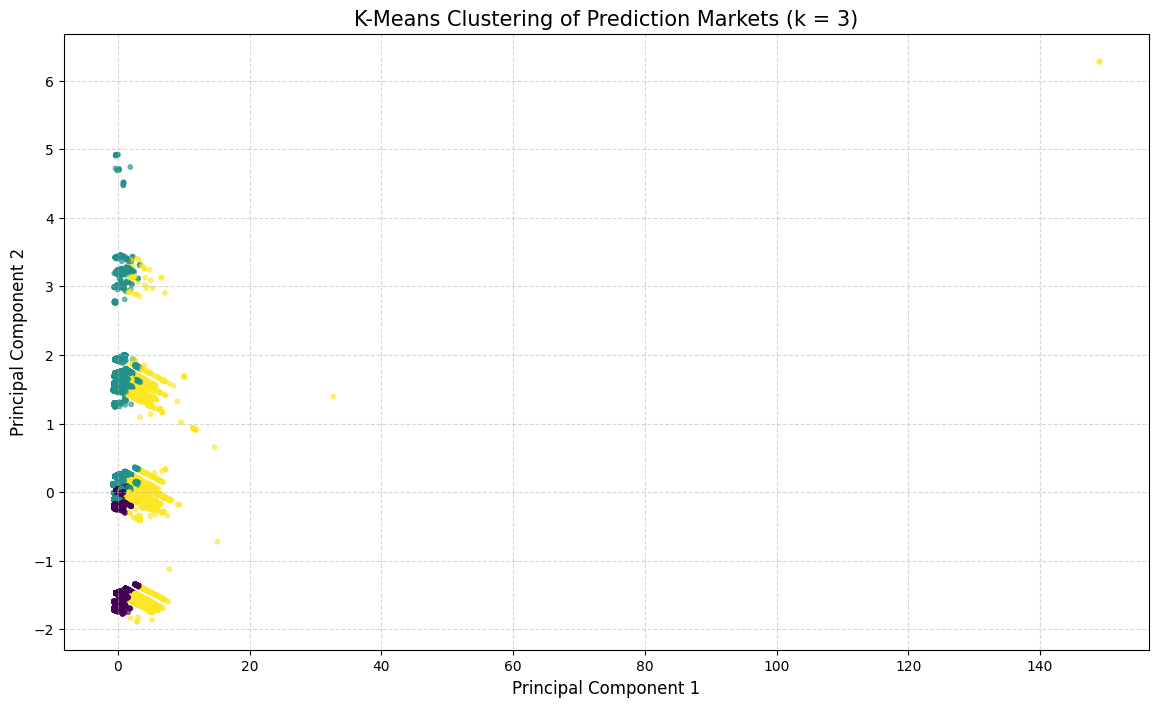

In [65]:
# Visualize the clusters using Principal Component Analysis (PCA)
# Reduce the feature matrix to two principal components
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

# Initialize the plot
plt.figure(figsize=(14, 8))

# Scatter plot of the first two principal components
plt.scatter(coords[:, 0], coords[:, 1],
            c=df_markets["cluster_kmeans_3"],
            cmap="viridis",
            s=10,
            alpha=0.6)

# Configure plot
plt.title("K-Means Clustering of Prediction Markets (k = 3)", fontsize=15)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

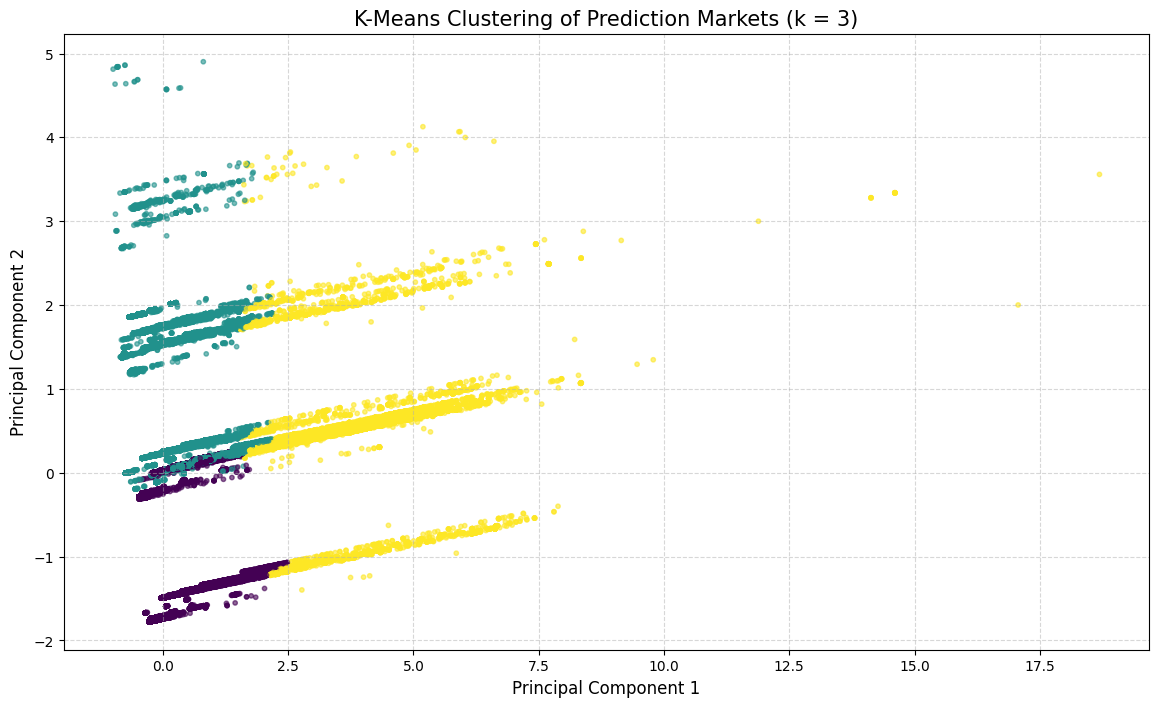

In [70]:
# Remove the two extreme outliers for visualization only
mask = df_markets["rewardsMinSize"] < 10000
X_plot = X[mask]
clusters_plot = df_markets.loc[mask, "cluster_kmeans_3"]

# Visualize the clusters using Principal Component Analysis (PCA)
pca = PCA(n_components=2)
coords = pca.fit_transform(X_plot)

# Initialize the plot
plt.figure(figsize=(14, 8))

# Scatter plot of the first two principal components
plt.scatter(coords[:, 0], coords[:, 1],
            c=clusters_plot,
            cmap="viridis",
            s=10,
            alpha=0.6)

# Configure plot
plt.title("K-Means Clustering of Prediction Markets (k = 3)", fontsize=15)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

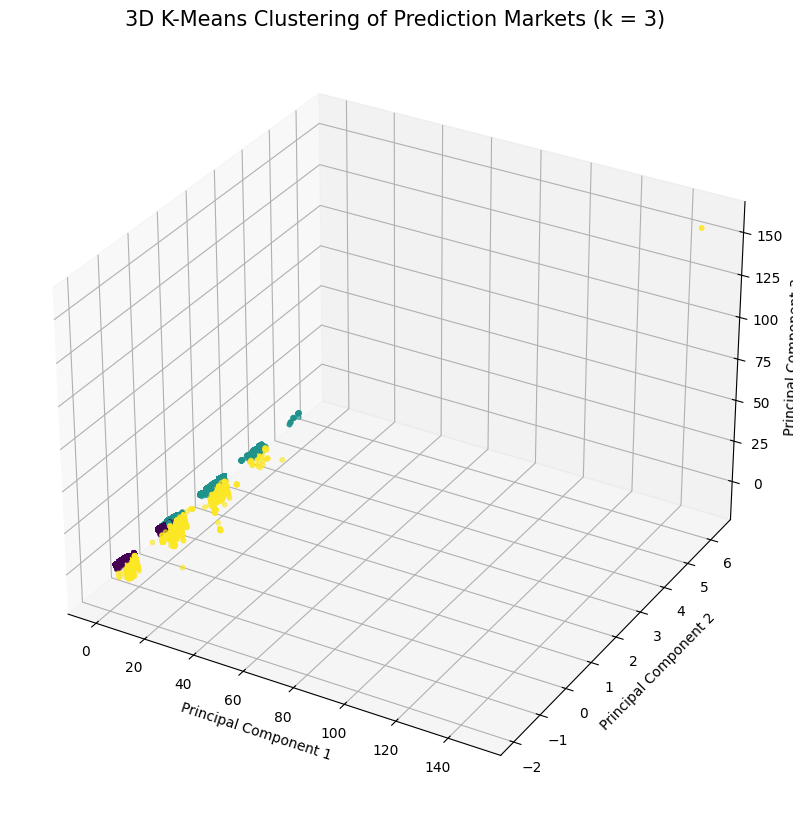

In [68]:
# Increase dimensionality reduction to three principal components
pca = PCA(n_components=3)
coords = pca.fit_transform(X)

# Setup the 3D plotting environment
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

# Generate a 3D scatter plot
ax.scatter(coords[:, 0],
           coords[:, 1],
           coords[:, 2],
           c=df_markets["cluster_kmeans_3"],
           cmap="viridis",
           s=10,
           alpha=0.6)

# Configure plot
ax.set_title("3D K-Means Clustering of Prediction Markets (k = 3)", fontsize=15)
ax.set_xlabel("Principal Component 1", fontsize=10)
ax.set_ylabel("Principal Component 2", fontsize=10)
ax.set_zlabel("Principal Component 3", fontsize=10)

plt.show()

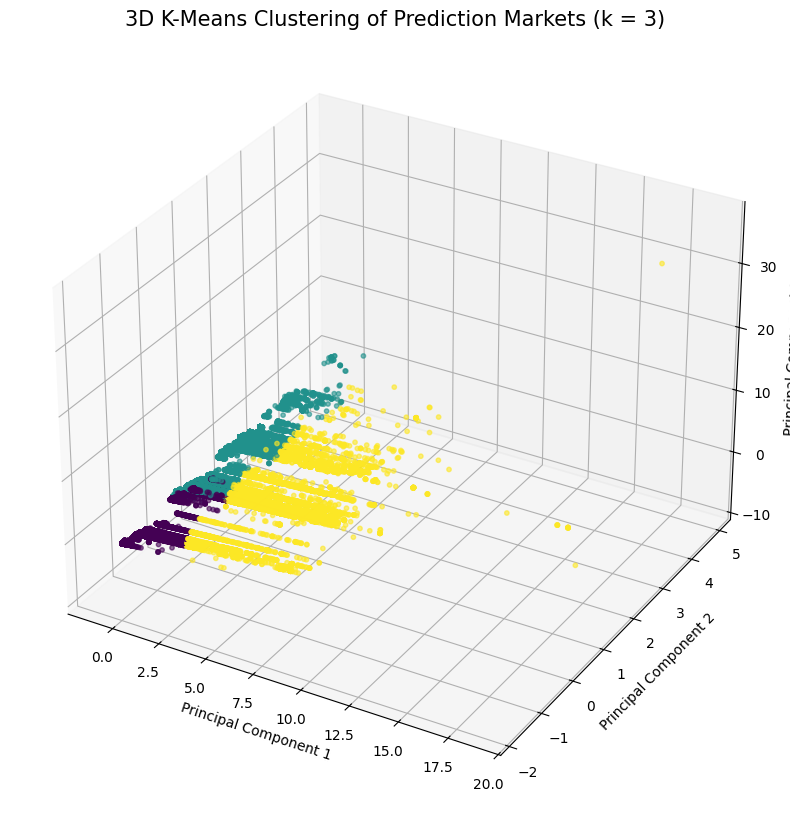

In [72]:
# Remove the two extreme outliers for visualization only
mask = df_markets["rewardsMinSize"] < 10000
X_plot = X[mask]
clusters_plot = df_markets.loc[mask, "cluster_kmeans_3"]

# Reduce the feature matrix to three principal components
pca = PCA(n_components=3)
coords = pca.fit_transform(X_plot)

# Setup the 3D plotting environment
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

# Generate a 3D scatter plot
ax.scatter(coords[:, 0],
           coords[:, 1],
           coords[:, 2],
           c=clusters_plot,
           cmap="viridis",
           s=10,
           alpha=0.6)

# Configure plot
ax.set_title("3D K-Means Clustering of Prediction Markets (k = 3)", fontsize=15)
ax.set_xlabel("Principal Component 1", fontsize=10)
ax.set_ylabel("Principal Component 2", fontsize=10)
ax.set_zlabel("Principal Component 3", fontsize=10)

plt.show()

## k = 5

In [54]:
kmeans = KMeans(n_clusters=5, random_state=42)
df_markets["cluster_kmeans_5"] = kmeans.fit_predict(X)

print(df_markets["cluster_kmeans_5"].value_counts().sort_index())

cluster_kmeans_5
0    46059
1    44599
2    11225
3    59413
4    31170
Name: count, dtype: int64


In [55]:
df_markets.groupby("cluster_kmeans_5")[numerical_features + dummy_features].mean().round(2)

,duration,rewardsMinSize,number_of_categories,politics,sports,esports,crypto,finance,business,technology_ai,geopolitics,culture,science,outcome_yes_no,outcome_up_down,outcome_over_under,outcome_other
cluster_kmeans_5,,,,,,,,,,,,,,,,,
0,7.71,2.82,1.04,0.00,0.93,0.08,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.31,0.00,0.17,0.53
1,1.98,1.55,1.00,0.00,0.00,0.00,0.99,0.01,0.01,0.00,0.00,0.00,0.00,0.06,0.94,0.00,0.00
2,221.52,56.56,1.01,0.28,0.46,0.04,0.05,0.04,0.03,0.01,0.03,0.08,0.00,0.99,0.00,0.00,0.01
3,13.66,22.29,0.36,0.13,0.01,0.00,0.02,0.01,0.03,0.00,0.02,0.04,0.08,0.67,0.01,0.13,0.20
4,7.23,10.69,2.02,0.07,0.15,0.07,0.76,0.05,0.81,0.02,0.04,0.05,0.00,0.98,0.00,0.00,0.02


### Cluster interpretation

Based on the selected features, the K-Means algorithm identifies five distinct types of prediction markets:

- **Cluster 0 – Sports Markets:** Markets are almost exclusively related to sports, have short durations, low reward sizes, and contain a variety of outcome types.

- **Cluster 1 – Crypto Markets:** Markets are almost entirely crypto-related, have very short durations, and predominantly use *Up/Down* outcomes.

- **Cluster 2 – Long-Term High-Reward Markets:** Markets are characterized by long durations, high minimum rewards, and are almost exclusively *Yes/No* markets.

- **Cluster 3 – General Short-Term Markets:** Markets have moderate reward sizes, relatively short durations, and cover a broad mix of categories without a dominant topic.

- **Cluster 4 – Multi-Category Markets:** Markets often belong to multiple categories, frequently combine crypto and business topics, and are primarily structured as *Yes/No* markets.

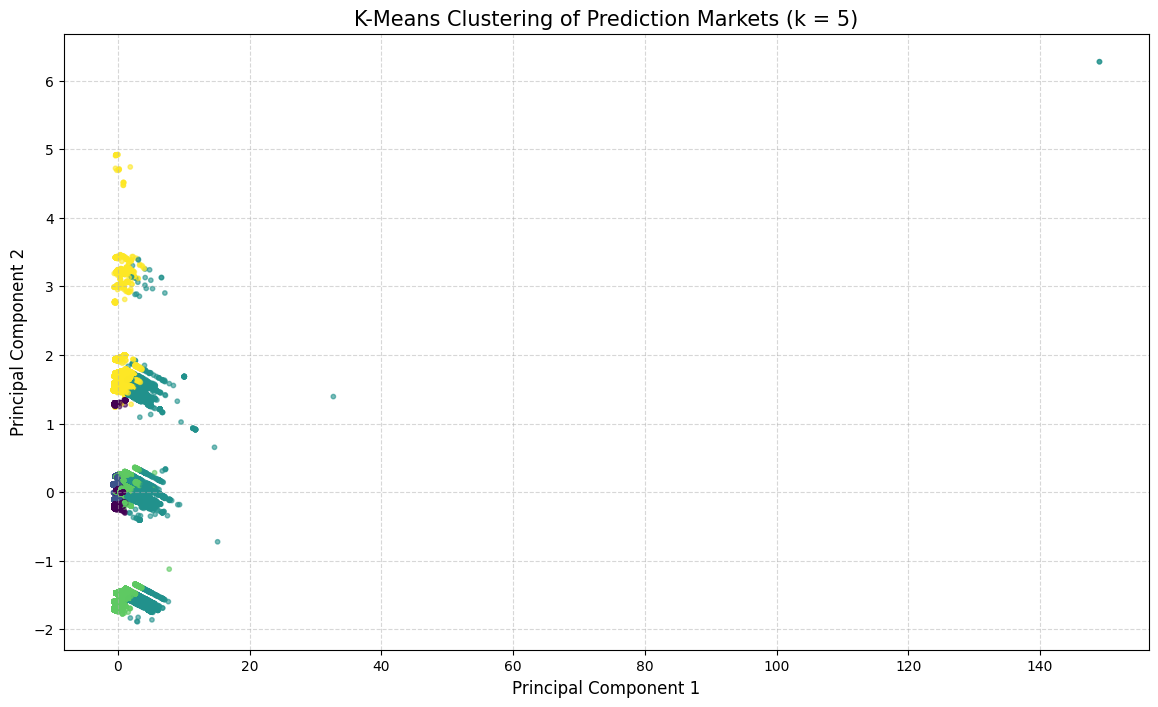

In [67]:
# Visualize the clusters using Principal Component Analysis (PCA)
# Reduce the feature matrix to two principal components
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

# Initialize the plot
plt.figure(figsize=(14, 8))

# Scatter plot of the first two principal components
plt.scatter(coords[:, 0], coords[:, 1],
            c=df_markets["cluster_kmeans_5"],
            cmap="viridis",
            s=10,
            alpha=0.6)

# Configure plot
plt.title("K-Means Clustering of Prediction Markets (k = 5)", fontsize=15)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

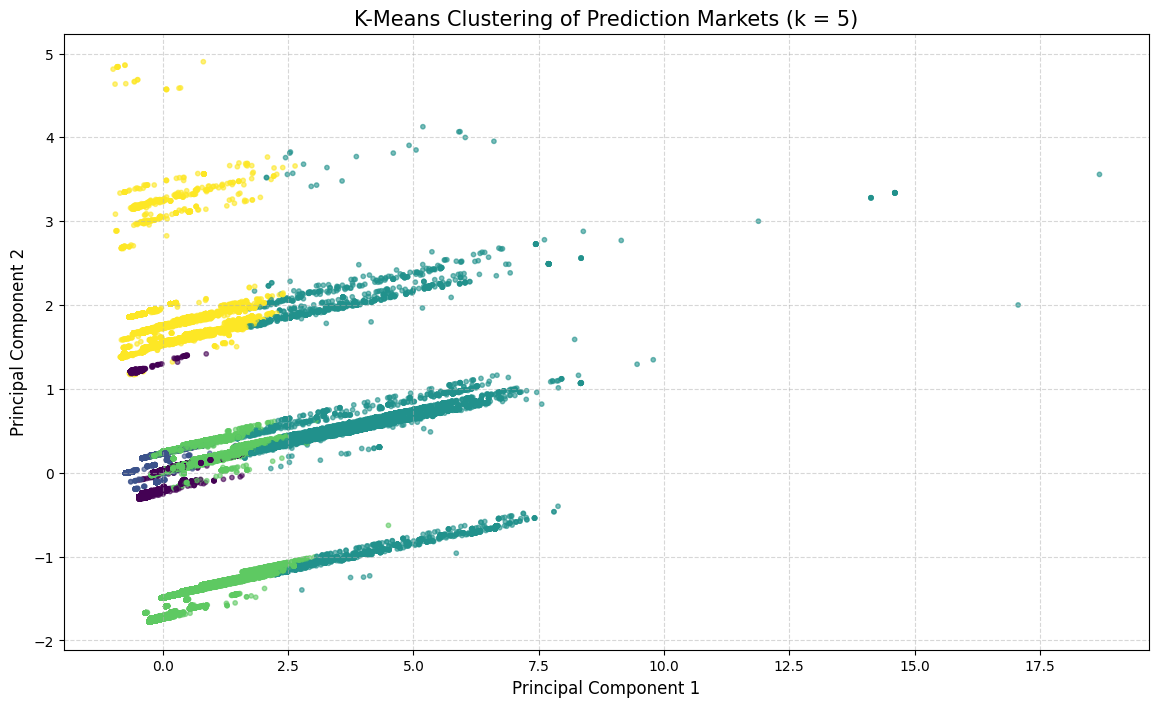

In [71]:
mask = df_markets["rewardsMinSize"] < 10000
X_plot = X[mask]
clusters_plot = df_markets.loc[mask, "cluster_kmeans_5"]

# Visualize the clusters using Principal Component Analysis (PCA)
pca = PCA(n_components=2)
coords = pca.fit_transform(X_plot)

# Initialize the plot
plt.figure(figsize=(14, 8))

# Scatter plot of the first two principal components
plt.scatter(coords[:, 0], coords[:, 1],
            c=clusters_plot,
            cmap="viridis",
            s=10,
            alpha=0.6)

# Configure plot
plt.title("K-Means Clustering of Prediction Markets (k = 5)", fontsize=15)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

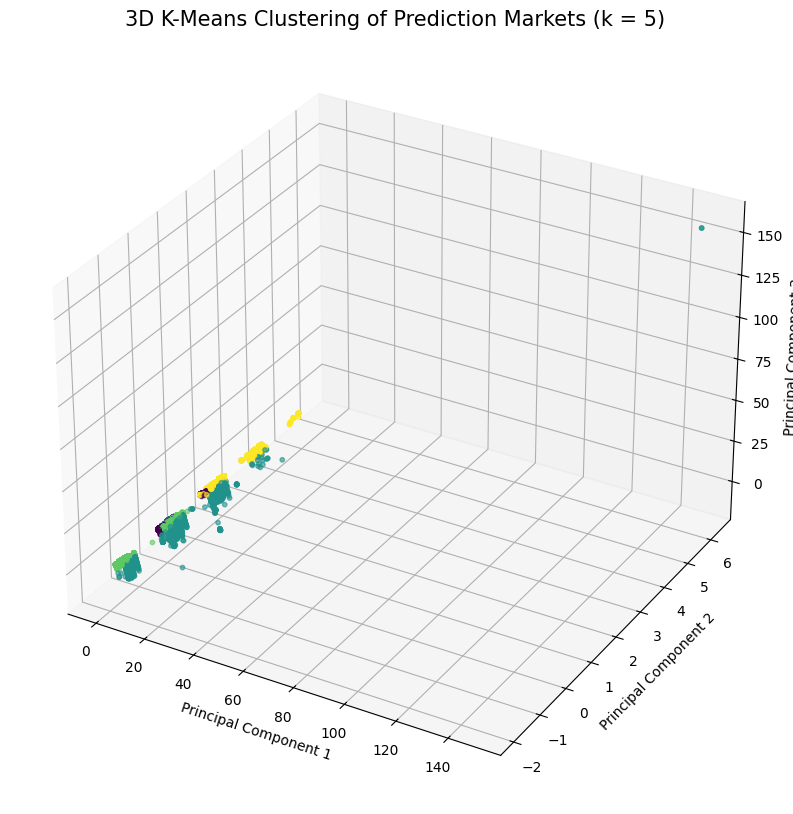

In [69]:
# Increase dimensionality reduction to three principal components
pca = PCA(n_components=3)
coords = pca.fit_transform(X)

# Setup the 3D plotting environment
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

# Generate a 3D scatter plot
ax.scatter(coords[:, 0],
           coords[:, 1],
           coords[:, 2],
           c=df_markets["cluster_kmeans_5"],
           cmap="viridis",
           s=10,
           alpha=0.6)

# Configure plot
ax.set_title("3D K-Means Clustering of Prediction Markets (k = 5)", fontsize=15)
ax.set_xlabel("Principal Component 1", fontsize=10)
ax.set_ylabel("Principal Component 2", fontsize=10)
ax.set_zlabel("Principal Component 3", fontsize=10)

plt.show()

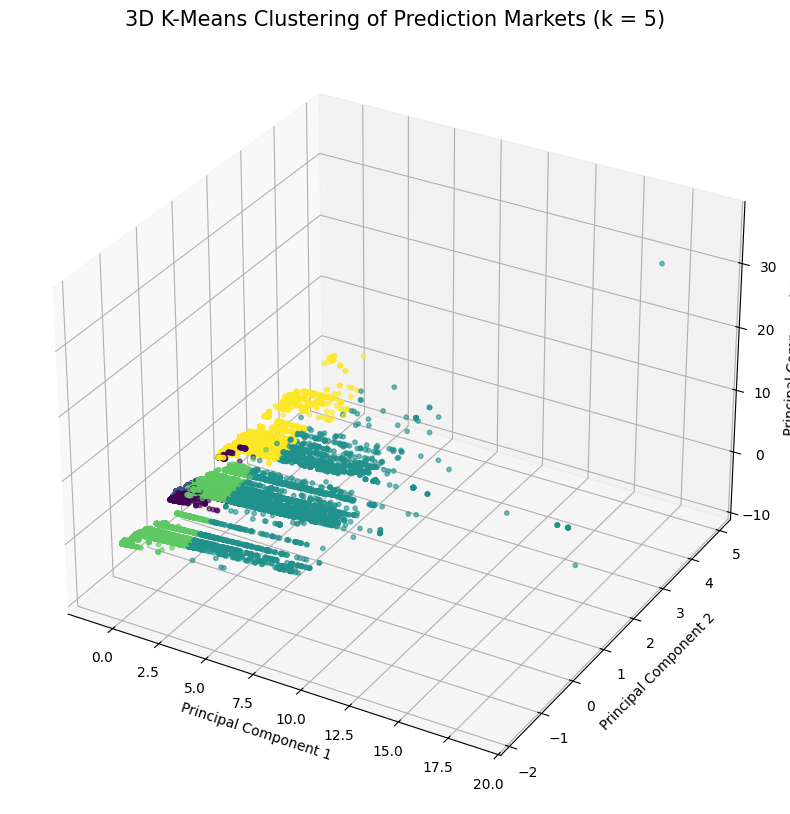

In [73]:
# Remove the two extreme outliers for visualization only
mask = df_markets["rewardsMinSize"] < 10000
X_plot = X[mask]
clusters_plot = df_markets.loc[mask, "cluster_kmeans_5"]

# Reduce the feature matrix to three principal components
pca = PCA(n_components=3)
coords = pca.fit_transform(X_plot)

# Setup the 3D plotting environment
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

# Generate a 3D scatter plot
ax.scatter(coords[:, 0],
           coords[:, 1],
           coords[:, 2],
           c=clusters_plot,
           cmap="viridis",
           s=10,
           alpha=0.6)

# Configure plot
ax.set_title("3D K-Means Clustering of Prediction Markets (k = 5)", fontsize=15)
ax.set_xlabel("Principal Component 1", fontsize=10)
ax.set_ylabel("Principal Component 2", fontsize=10)
ax.set_zlabel("Principal Component 3", fontsize=10)

plt.show()

## k = 7

In [59]:
kmeans = KMeans(n_clusters=7, random_state=42)
df_markets["cluster_kmeans_7"] = kmeans.fit_predict(X)

print(df_markets["cluster_kmeans_7"].value_counts().sort_index())

cluster_kmeans_7
0    32076
1    42083
2    10112
3    38014
4    30023
5    40156
6        2
Name: count, dtype: int64


Although the Silhouette Score is highest for **k = 7**, this solution is not considered further because one cluster consists of only **two observations**, indicating that it mainly captures outliers rather than a meaningful market segment.

In [61]:
# drop the cluster_kmeans_7 column 

df_markets.drop(columns=["cluster_kmeans_7"], inplace=True)

KeyError: "['cluster_kmeans_7'] not found in axis"

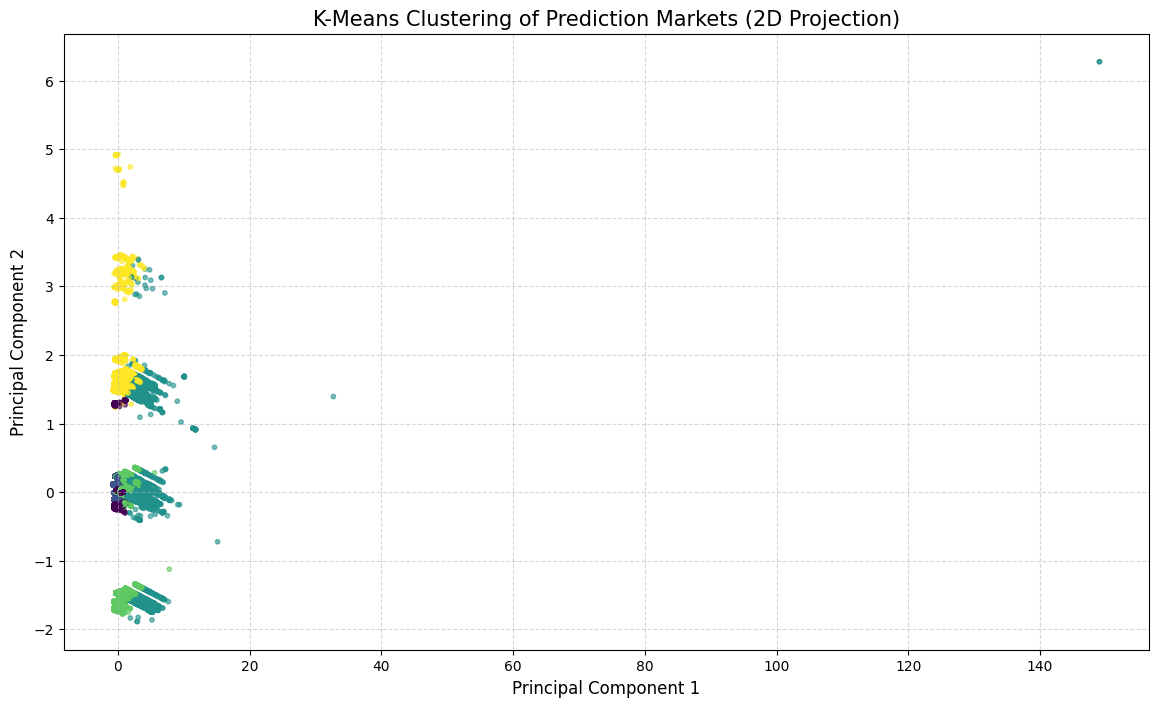

In [40]:
# Visualize the clusters using Principal Component Analysis (PCA)
# Reduce the feature matrix to two principal components
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

# Initialize the plot
plt.figure(figsize=(14, 8))

# Scatter plot of the first two principal components
plt.scatter(coords[:, 0], coords[:, 1],
            c=df_markets["cluster_kmeans"],
            cmap="viridis",
            s=10,
            alpha=0.6)

# Configure plot
plt.title("K-Means Clustering of Prediction Markets (2D Projection)", fontsize=15)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

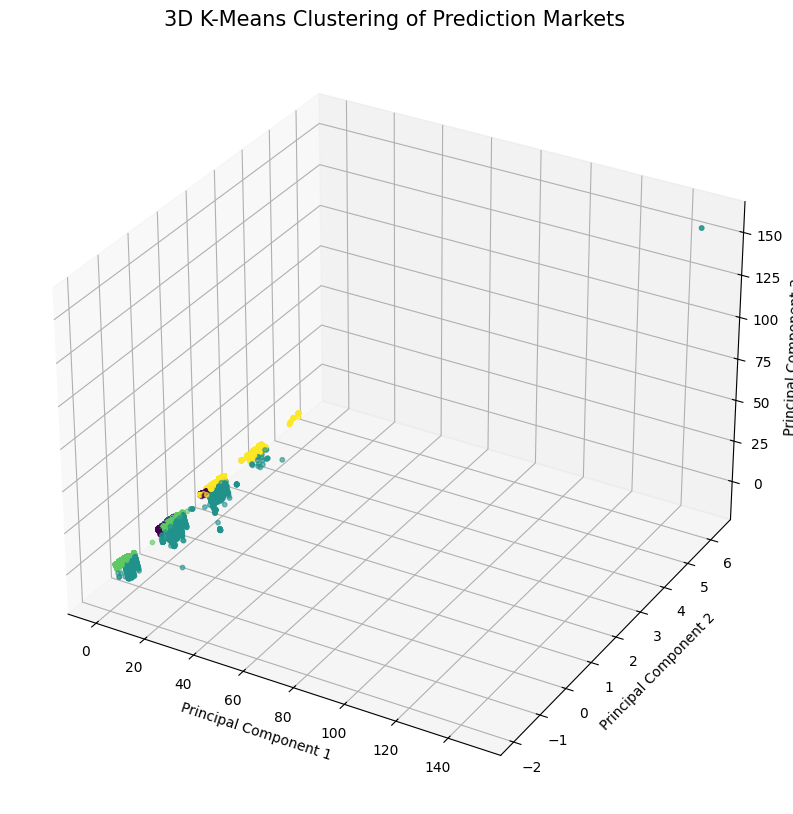

In [41]:
# Increase dimensionality reduction to three principal components
pca = PCA(n_components=3)
coords = pca.fit_transform(X)

# Setup the 3D plotting environment
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

# Generate a 3D scatter plot
ax.scatter(coords[:, 0],
           coords[:, 1],
           coords[:, 2],
           c=df_markets["cluster_kmeans"],
           cmap="viridis",
           s=10,
           alpha=0.6)

# Configure plot
ax.set_title("3D K-Means Clustering of Prediction Markets", fontsize=15)
ax.set_xlabel("Principal Component 1", fontsize=10)
ax.set_ylabel("Principal Component 2", fontsize=10)
ax.set_zlabel("Principal Component 3", fontsize=10)

plt.show()

# Hierarchical Clustering

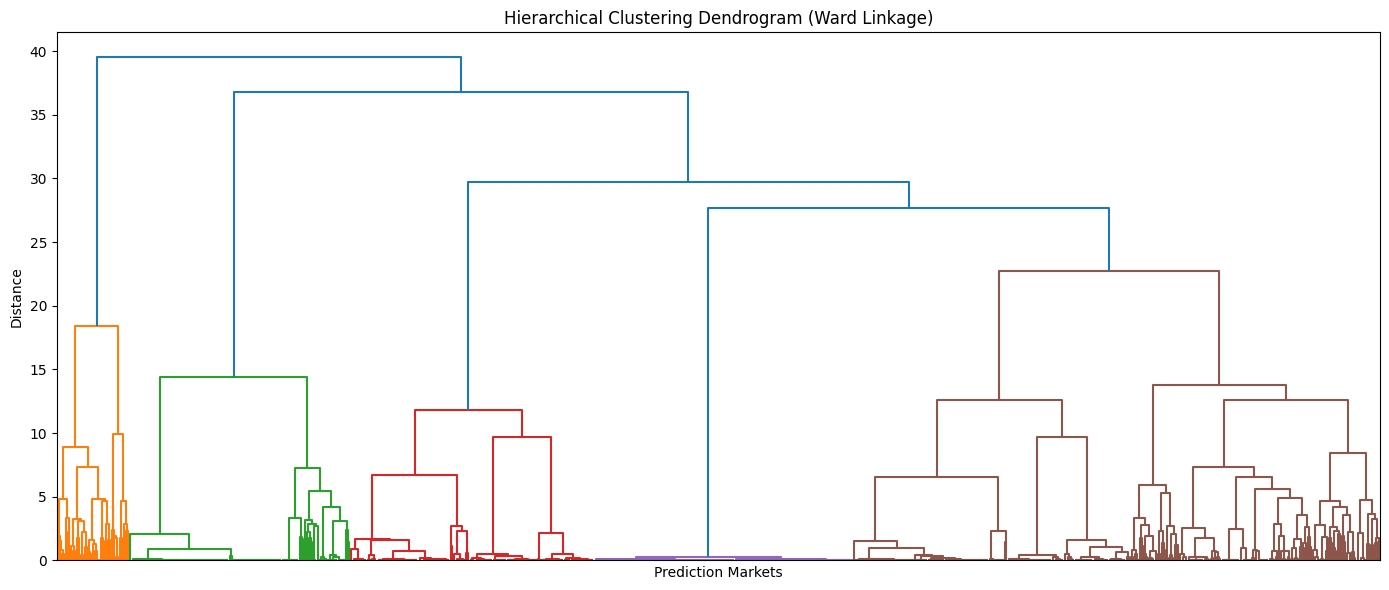

In [44]:
# Draw a random sample for visualization
sample = X.sample(n=1000, random_state=42)

# Compute Euclidean distances between markets
distance = pdist(sample, metric="euclidean")

# Hierarchical clustering using Ward linkage
linkage_matrix = linkage(distance, method="ward")

# Plot dendrogram
plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, no_labels=True)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Prediction Markets")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

The dendrogram suggests the presence of several distinct groups of prediction markets. Although no single cut-off point is unambiguous, a partition into approximately five clusters appears reasonable and is consistent with the results of the Elbow Method, the Silhouette Score, and the K-Means clustering.

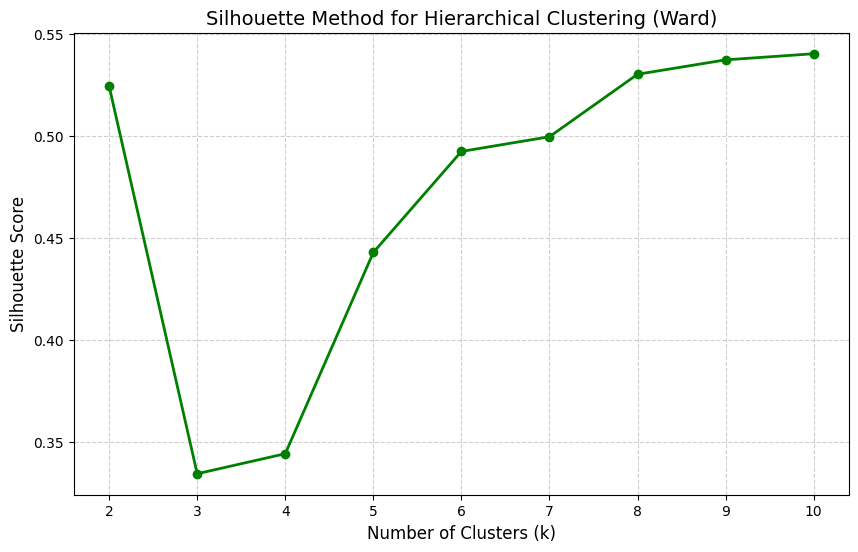

The optimal number of clusters based on the Silhouette Score is: 10


In [45]:
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score

# Define the range for testing clusters
K_range = range(2, 11)
hierarchical_silhouette_scores = []

# Iterate through different cluster counts
for k in K_range:
    # Cut the dendrogram into k clusters
    labels = fcluster(linkage_matrix, k, criterion='maxclust')

    # Calculate the Silhouette Score
    score = silhouette_score(sample, labels)
    hierarchical_silhouette_scores.append(score)

# Plot the Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(K_range, hierarchical_silhouette_scores, 'go-', linewidth=2)
plt.title('Silhouette Method for Hierarchical Clustering (Ward)', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Identify the optimal number of clusters
best_k = K_range[np.argmax(hierarchical_silhouette_scores)]
print(f"The optimal number of clusters based on the Silhouette Score is: {best_k}")

The Silhouette Score for hierarchical clustering reaches a local optimum around **k = 6** and shows only marginal improvements for larger numbers of clusters. Therefore, we select **six clusters** as a suitable balance between cluster quality and interpretability for the hierarchical clustering analysis.

In [46]:
from sklearn.cluster import AgglomerativeClustering

# Fit hierarchical clustering
agg = AgglomerativeClustering(n_clusters=6, linkage="ward")

# Assign cluster labels
df_markets["cluster_hierarchical"] = agg.fit_predict(X)

# Display cluster sizes
print(df_markets["cluster_hierarchical"].value_counts().sort_index())

MemoryError: Unable to allocate 138. GiB for an array with shape (18521484345,) and data type float64

In [47]:
from sklearn.cluster import AgglomerativeClustering

# Draw a random sample
sample = X.sample(n=1000, random_state=42)

# Fit hierarchical clustering
agg = AgglomerativeClustering(n_clusters=6, linkage="ward")

# Assign cluster labels
sample_labels = agg.fit_predict(sample)

# Store results in a DataFrame
sample_results = sample.copy()
sample_results["cluster_hierarchical"] = sample_labels

# Display cluster sizes
print(sample_results["cluster_hierarchical"].value_counts().sort_index())

cluster_hierarchical
0     55
1    189
2    166
3    185
4    196
5    209
Name: count, dtype: int64


In [49]:
sample_results.groupby("cluster_hierarchical")[numerical_features + dummy_features].mean().round(2)

,duration,rewardsMinSize,number_of_categories,politics,sports,esports,crypto,finance,business,technology_ai,geopolitics,culture,science,outcome_yes_no,outcome_up_down,outcome_over_under,outcome_other
cluster_hierarchical,,,,,,,,,,,,,,,,,
0,3.22,1.65,0.27,0.38,0.40,0.11,0.09,0.02,0.07,0.00,0.02,0.05,0.00,0.96,0.00,0.00,0.04
1,0.26,0.60,0.14,0.25,0.18,0.02,0.17,0.04,0.13,0.01,0.04,0.10,0.12,0.97,0.02,0.01,0.01
2,-0.26,-0.23,1.65,0.04,0.27,0.16,0.72,0.02,0.73,0.01,0.01,0.05,0.00,0.90,0.00,0.01,0.10
3,-0.22,-0.14,-1.56,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.48,0.00,0.23,0.29
4,-0.34,-0.28,0.04,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
5,-0.28,-0.26,0.04,0.00,0.93,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.24,0.00,0.21,0.56


In [51]:
sample_original = df_markets.loc[sample.index].copy()
sample_original["cluster_hierarchical"] = sample_labels

sample_original.groupby("cluster_hierarchical")[numerical_features + dummy_features].mean().round(2)

,duration,rewardsMinSize,number_of_categories,politics,sports,esports,crypto,finance,business,technology_ai,geopolitics,culture,science,outcome_yes_no,outcome_up_down,outcome_over_under,outcome_other
cluster_hierarchical,,,,,,,,,,,,,,,,,
0,201.87,88.36,1.15,0.38,0.40,0.11,0.09,0.02,0.07,0.00,0.02,0.05,0.00,0.96,0.00,0.00,0.04
1,35.21,40.37,1.06,0.25,0.18,0.02,0.17,0.04,0.13,0.01,0.04,0.10,0.12,0.97,0.02,0.01,0.01
2,5.76,2.47,2.01,0.04,0.27,0.16,0.72,0.02,0.73,0.01,0.01,0.05,0.00,0.90,0.00,0.01,0.10
3,8.19,6.76,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.48,0.00,0.23,0.29
4,1.37,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
5,5.04,1.00,1.00,0.00,0.93,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.24,0.00,0.21,0.56


### Cluster interpretation

Based on the hierarchical clustering results, six distinct types of prediction markets can be identified:

- **Cluster 0 – Long-Term High-Reward Markets:** Markets with the longest durations (≈202 days), the highest reward sizes, and predominantly *Yes/No* outcomes.

- **Cluster 1 – Medium-Term General Markets:** Markets with medium durations (≈35 days), moderate reward sizes, and mainly *Yes/No* outcomes across a broad range of topics.

- **Cluster 2 – Multi-Category Crypto & Business Markets:** Short-term markets that frequently combine crypto and business topics, belong to multiple categories, and are primarily *Yes/No* markets.

- **Cluster 3 – Niche Markets:** Markets without a dominant category, low reward sizes, and a mix of different outcome structures.

- **Cluster 4 – Crypto Up/Down Markets:** Very short-term markets exclusively related to crypto with *Up/Down* outcomes.

- **Cluster 5 – Sports Markets:** Short-term markets almost exclusively related to sports, with relatively low reward sizes and a variety of outcome types.